In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import geopandas as gpd
from pathlib import Path
import fiona 
import numpy as np
import pandas as pd
import logging
# Plotting
import matplotlib.pyplot as plt
# Pour la basemap
import contextily as cx
# Potentiel solaire package

In [4]:

from potentiel_solaire.attach_buildings_to_schools import attach_buildings_to_schools
from potentiel_solaire.constants import DATA_FOLDER
from potentiel_solaire.constants import CRS, ALGORITHME_FOLDER, DATA_FOLDER
from potentiel_solaire.sources.bd_topo import extract_bd_topo, get_topo_zones_of_interest, \
    get_topo_buildings_of_interest
from potentiel_solaire.sources.bd_pci import extract_bd_pci
from potentiel_solaire.sources.bd_solar_irradiation import extract_bd_irradiation
from potentiel_solaire.sources.schools_establishments import extract_schools_establishments, \
    get_schools_establishments_of_interest
from potentiel_solaire.features.solar_potential import calculate_solar_potential
from potentiel_solaire.aggregate import aggregate_solar_potential_by
from potentiel_solaire.logger import get_logger

logger = get_logger() 
logger.setLevel(logging.ERROR)

In [5]:
code_departement = "093"
compare_with_idf = True

# Imports & setup

C:\Users\thiba\AppData\Local\Temp\ipykernel_1936\2162312035.py:4: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  dpts[dpts.code == "93"].plot(column="nom",legend=True, categorical = True, ax = ax, color="green",alpha=0.5)
C:\Users\thiba\AppData\Local\Temp\ipykernel_1936\2162312035.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


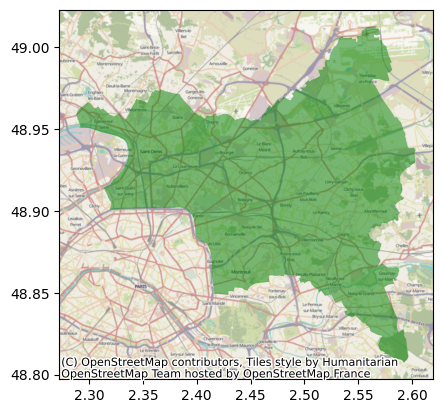

In [6]:
dpts = gpd.read_file(DATA_FOLDER / "contour-des-departements.geojson").to_crs(4326)
ShapeNT = dpts[dpts.code == "93"].geometry
fig, ax = plt.subplots()
dpts[dpts.code == "93"].plot(column="nom",legend=True, categorical = True, ax = ax, color="green",alpha=0.5)
cx.add_basemap(ax, crs=dpts.crs)
fig.show()

In [7]:
# get data and get paths
schools_establishments_path = extract_schools_establishments()
bd_topo_path = extract_bd_topo(code_departement=code_departement)
bd_pci_path = extract_bd_pci(code_departement=code_departement)

In [8]:
schools_establishments = get_schools_establishments_of_interest(
    schools_filepath=schools_establishments_path,
    code_departement=code_departement,
    types_etablissements=['Ecole', 'Lycée', 'Collège'],
    statut_public_prive="Public",
    etat="OUVERT",
    crs=CRS
)
nb_schools = schools_establishments.shape[0]
print(f"Nb d'établissements scolaires: {nb_schools}")


Nb d'établissements scolaires: 1130


In [9]:
educational_zones = get_topo_zones_of_interest(
    bd_topo_path=bd_topo_path,
    geom_of_interest=ShapeNT,
    categories=["Science et enseignement"],
    natures=['Collège', 'Lycée', 'Enseignement primaire'],
    crs=CRS
)
nb_educational_zones = educational_zones.shape[0]
print("Nb de zones d'éducations: ", nb_educational_zones)

d:\datafrogood\13_potentiel_solaire\algorithme\.venv\Lib\site-packages\pyogrio\core.py:279: RuntimeWarning: Field format 'character varying' not supported
  return ogr_read_info(
d:\datafrogood\13_potentiel_solaire\algorithme\.venv\Lib\site-packages\pyogrio\core.py:279: RuntimeWarning: Field format 'character varying(256)' not supported
  return ogr_read_info(
d:\datafrogood\13_potentiel_solaire\algorithme\.venv\Lib\site-packages\pyogrio\core.py:279: RuntimeWarning: Field format 'character varying(30)' not supported
  return ogr_read_info(
d:\datafrogood\13_potentiel_solaire\algorithme\.venv\Lib\site-packages\pyogrio\core.py:279: RuntimeWarning: Field format 'timestamp with time zone' not supported
  return ogr_read_info(
d:\datafrogood\13_potentiel_solaire\algorithme\.venv\Lib\site-packages\geopandas\io\file.py:497: UserWarning: More than one layer found in 'BDT_3-4_GPKG_LAMB93_D093-ED2024-12-15.gpkg': 'troncon_de_route' (default), 'route_numerotee_ou_nommee', 'itineraire_autre', 'tro

Nb de zones d'éducations:  1090


In [10]:
# Preparation 'educational_zones'
educational_zones = educational_zones.dropna(subset=["identifiants_sources"])
educational_zones["identifiants_sources"] = educational_zones["identifiants_sources"].apply(lambda x: [y.strip() for y in str(x).replace("MEN:","").split("/")])
educational_zones = educational_zones.explode('identifiants_sources')

# Recollement
educational_zones_attached_to_schools = pd.merge(
    educational_zones,
    schools_establishments[["identifiant_de_l_etablissement","nom_etablissement", "code_commune"]],
    left_on='identifiants_sources', right_on='identifiant_de_l_etablissement',
    how="inner"
)

educational_zones_attached_to_schools = educational_zones_attached_to_schools.dropna(subset=["cleabs","identifiants_sources"])

In [11]:
schools_establishments = schools_establishments.dropna(subset=["identifiant_de_l_etablissement"])
schools_establishments

,identifiant_de_l_etablissement,nom_etablissement,type_etablissement,statut_public_prive,adresse_1,adresse_2,adresse_3,code_postal,code_commune,nom_commune,...,code_type_contrat_prive,pial,etablissement_mere,type_rattachement_etablissement_mere,code_circonscription,code_zone_animation_pedagogique,libelle_zone_animation_pedagogique,code_bassin_formation,libelle_bassin_formation,geometry
11296,0930171F,Ecole élémentaire Diderot 1,Ecole,Public,246 rue de la République,None,93700 DRANCY,93700,93029,Drancy,...,99,None,None,None,0932685N,None,None,None,None,POINT (2.42603 48.9263)
11298,0930173H,Ecole élémentaire Marcel Cachin,Ecole,Public,77 avenue de la division Leclerc,None,93500 PANTIN,93500,93055,Pantin,...,99,None,None,None,0931044E,None,None,None,None,POINT (2.4137 48.91095)
11300,0930194F,Ecole élémentaire Jean Macé,Ecole,Public,46 rue Henri Barbusse,None,93300 AUBERVILLIERS,93300,93001,Aubervilliers,...,99,None,None,None,0931037X,None,None,None,None,POINT (2.38972 48.90469)
11302,0930203R,Ecole élémentaire Noue Caillet,Ecole,Public,34 avenue Jean Moulin,None,93140 BONDY,93140,93010,Bondy,...,99,None,None,None,0931266W,None,None,None,None,POINT (2.48062 48.91225)
11304,0930210Y,Ecole élémentaire André Diez,Ecole,Public,38 avenue Lénine,None,93200 ST DENIS,93200,93066,Saint-Denis,...,99,None,None,None,0932609F,None,None,None,None,POINT (2.36598 48.94175)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68539,0931708B,Section d'enseignement général et professionne...,Collège,Public,59 RUE DU LAVOIR,BP 103,93370 MONTFERMEIL,93370,93047,Montfermeil,...,99,None,0931707A,FILIERE OU DEPARTEMENT OU SECTION,0932257Y,None,None,None,None,POINT (2.57807 48.8996)
68540,0931743P,Section d'enseignement professionnel du Lycée ...,Lycée,Public,2 rue du Château,None,93260 LES LILAS,93260,93045,Les Lilas,...,99,None,0932073Y,ANNEXE GEOGRAPHIQUE,None,None,None,None,None,POINT (2.42134 48.8833)
68541,0931814S,Section d'enseignement général et professionne...,Collège,Public,2 rue LAVOISIER,None,93500 PANTIN,93500,93055,Pantin,...,99,None,0931713G,FILIERE OU DEPARTEMENT OU SECTION,0932257Y,None,None,None,None,POINT (2.41969 48.88937)
68542,0932228S,Section d'enseignement professionnel du Lycée ...,Lycée,Public,8 RUE PIERRE AUDAT,None,93420 VILLEPINTE,93420,93078,Villepinte,...,99,None,0931584S,ANNEXE GEOGRAPHIQUE,None,None,None,None,None,POINT (2.54654 48.96013)


## Ecoles non rattachees a une zone 

In [12]:

def get_school_not_attached(
    dataframe_zone_school : gpd.GeoDataFrame,
    dataframe_school : gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    ''' Permet de récupérer les écoles non rattachées à une zone'''
    
    #On récupères les idenifiants dans le dataframe zone + école
    identifiants_in_zone = dataframe_zone_school['identifiants_sources']
    
    #On regarde ceux qui ne sont pas en commun
    not_in_zones = dataframe_school[~dataframe_school['identifiant_de_l_etablissement'].isin(identifiants_in_zone)].copy()

    return not_in_zones



## Recuperation nouveau point

In [13]:
# Ma fonction de call à l'API pour récupérer les cordonnées
from shapely import Geometry
from shapely.geometry import Point
import requests 

def get_full_adress(
    not_in_zones : gpd.GeoDataFrame,
) -> gpd.GeoDataFrame:
    ''' Permet de récupérer l'adresse complète'''
    
    not_in_zones.loc[:,'adresse_complete'] = not_in_zones['adresse_1'].str.cat(not_in_zones['adresse_3'], sep=' ')
    return not_in_zones




def get_coordinates_API(
    postal_address : str,
    ) -> Geometry :
    
    ''' Permet de récupérer de nouvelles coordonnées a partir de l'adresse postale'''

# j'essaie avec Nominatim d'abord  
    try:
        user_agent = {"User-Agent" : "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:135.0) Gecko/20100101 Firefox/135.0"}
        link_main = 'https://nominatim.openstreetmap.org/search?q='
        link_end = '&format=json&limit=1'
        
        adress = postal_address.replace('  ', ' ').replace(' ', '+').replace(',','')
        api_url = link_main + adress + link_end
        r = requests.get(api_url, headers= user_agent).json()
        # print(r)
        coord = Point([r[0]['lon'], r[0]['lat']])   
        return coord
    #Si ca ne marche pas, j'essaie avec l'API du gouvernement
    except:
        try:   
            link_main = 'https://api-adresse.data.gouv.fr/search/?q='
            link = link_main + postal_address.replace('  ', ' ').replace(' ', '=').replace(',','').replace('-', '=')
            r = requests.get(link).json()
            coord = Point(r['features'][0]['geometry']['coordinates'])
            # print(coord)
            return coord
        # Sinon, je ressors un NaN
        except:
            return np.nan

    


In [14]:
not_in = get_school_not_attached(educational_zones_attached_to_schools, schools_establishments)

not_in = get_full_adress(not_in)
len(not_in)
#Ca prends 20 secondes.
# test['nvlle_geometry'] = test['adresse_complete'].apply(get_coordinates_API)

21

In [15]:
not_in.columns

Index(['identifiant_de_l_etablissement', 'nom_etablissement',
       'type_etablissement', 'statut_public_prive', 'adresse_1', 'adresse_2',
       'adresse_3', 'code_postal', 'code_commune', 'nom_commune',
       'code_departement', 'code_academie', 'code_region', 'ecole_maternelle',
       'ecole_elementaire', 'voie_generale', 'voie_technologique',
       'voie_professionnelle', 'telephone', 'fax', 'web', 'mail',
       'restauration', 'hebergement', 'ulis', 'apprentissage', 'segpa',
       'section_arts', 'section_cinema', 'section_theatre', 'section_sport',
       'section_internationale', 'section_europeenne', 'lycee_agricole',
       'lycee_militaire', 'lycee_des_metiers', 'post_bac',
       'appartenance_education_prioritaire', 'greta', 'siren_siret',
       'nombre_d_eleves', 'fiche_onisep', 'position', 'type_contrat_prive',
       'libelle_departement', 'libelle_academie', 'libelle_region',
       'coordx_origine', 'coordy_origine', 'epsg_origine',
       'nom_circonscription',

In [16]:
# Petit truc chelou ici 
print(f'Nb de nom commune unique {len(not_in['nom_commune'].unique())}')
print(f'Nb de CP unique {len(not_in['code_postal'].unique())}')
print(f'Nb de code communes uniques {len(not_in['code_commune'].unique())}')
print(f'Nb de CP + Ville unique {len(not_in['adresse_3'].unique())}')

Nb de nom commune unique 17
Nb de CP unique 18
Nb de code communes uniques 17
Nb de CP + Ville unique 18


In [17]:
not_in['code_commune']

21098    93001
21101    93005
21104    93014
21107    93007
21110    93073
21116    93006
35158    93053
36307    93070
40658    93071
65415    93066
65419    93031
65421    93001
65423    93029
65425    93066
68527    93005
68533    93059
68534    93029
68537    93078
68539    93047
68541    93055
68544    93032
Name: code_commune, dtype: object

## Calcul des la distance

### Je récupère la ville

Si une zone à une école d'assignée, je vais lui assigner le code postal de l'école 

In [18]:
def get_id_code_commune(
    dataframe_zone_school : gpd.GeoDataFrame,
    dataframe_zone : gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    ''' Récupère les binomes identifiants - code commune
    et merge avec le df de zones pour récupérer les codes communes'''
    
    identifiants_and_codes  = [(identifiant,code_commune) for identifiant, code_commune in 
                  zip(dataframe_zone_school['identifiant_de_l_etablissement'],
                      dataframe_zone_school['code_commune'])]
    
    
    identifiants_and_codes  = list(set(identifiants_and_codes ))
    df_id_and_codes = pd.DataFrame(identifiants_and_codes , columns=['identifiant', 'code_commune'])
    
    
    zones_with_code = pd.merge(
    dataframe_zone,
    df_id_and_codes,
    left_on='identifiants_sources', right_on='identifiant',
    how="inner"
)

    return zones_with_code



In [19]:
zone_with_CM = get_id_code_commune(educational_zones_attached_to_schools, educational_zones)

nb_cm_fct = len(zone_with_CM)
nb_zones = len(educational_zones)

print(f'df avec commune : {nb_cm_fct}\ndf de zones : {nb_zones}\nSoit une différence de {nb_zones-nb_cm_fct} ')

df avec commune : 1116
df de zones : 1288
Soit une différence de 172 


On passe aux calculs

In [20]:
def formatting_string_fuzzy (
  name_school_or_zone : str  
) -> str :
    '''Permet de formatter les strings pour le fuzzy match '''
    
    stop_words = ["section", "enseignement", "professionnel", "général", "et", "adapté", "collège", "école", "élémentaire",
                  "ecole", "maternelle", "elementaire", "primaire", "etablissement", "expérimental", "nouvelles",  "chances",
                  "du", "lycée"]
    formatted_string =  ' '.join(word.lower() for word in name_school_or_zone.lower().replace("'", " ").split(" ",) if word not in stop_words and len(word)>1)
    return formatted_string

In [ ]:
from shapely import distance
from difflib import SequenceMatcher as SM

def get_closest_zone(
    school_not_attached : gpd.GeoDataFrame,
    zone_with_CM : gpd.GeoDataFrame
) -> pd.Series:
    
    ''' Permet de récupérer la zone la plus proche 
    d'une école'''
    geom = school_not_attached['geometry']
    code = school_not_attached['code_commune']
    name_school_not_in_zone = school_not_attached['nom_etablissement']
    
    
    # Récupère la distance la plus faible et la zone associée
    liste_CM_zone = list(zone_with_CM[zone_with_CM['code_commune'] == code].to_crs(2154)['geometry'])
    liste_distance = [distance([zone], geom) for zone in liste_CM_zone]
    index_min_dist = np.argmin(liste_distance)
    
    closest_zone = zone_with_CM[zone_with_CM['code_commune'] == code].iloc[index_min_dist].to_frame().T
    closest_zone['id_school'] = school_not_attached['identifiant_de_l_etablissement']
    closest_zone['distance_en_m'] = round(liste_distance[index_min_dist][0], 2)
    # return closest_zone

    #Opère le fuzzy match
    
    #On formatte les strings 
    name_zone_formatted =  formatting_string_fuzzy(closest_zone['toponyme'].iloc[0])
    name_school_not_in_zone_formatted = formatting_string_fuzzy(name_school_not_in_zone)
    s = SM(None,
       name_zone_formatted,
       name_school_not_in_zone_formatted)
    
    closest_zone['sequence_matcher'] = round(s.ratio(), 2)
    
    return closest_zone


In [50]:
from geopandas import GeoDataFrame


def get_df_closest_zone(    
    school_not_attached : gpd.GeoDataFrame,
    zone_with_CM : gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    

    series = school_not_attached.to_crs(2154).apply(get_closest_zone, zone_with_CM = zone_with_CM, axis = 1)
    school_closest_to_zone = pd.concat(series.tolist())
    return GeoDataFrame(school_closest_to_zone, crs='EPSG:4326', geometry='geometry')

In [52]:
get_df_closest_zone(not_in.to_crs(2154), zone_with_CM)

,cleabs,categorie,nature,nature_detaillee,toponyme,statut_du_toponyme,importance,fictif,etat_de_l_objet,date_creation,...,methode_d_acquisition_planimetrique,precision_planimetrique,identifiant_voie_ban,nom_commercial,geometry,identifiant,code_commune,id_school,distance_en_m,sequence_matcher
146,SURFACTI0000000002555811,Science et enseignement,Collège,None,Collège Rosa Luxemburg,Collecté,5,False,En service,2006-05-22 16:31:28.175000,...,BDTopo,2.5,None,None,"MULTIPOLYGON (((2.37531 48.91426, 2.37532 48.9...",0932272P,93001,0931444P,4.57,1.00
727,SURFACTI0000000245007035,Science et enseignement,Collège,None,Collège Pablo Neruda,Collecté,5,False,En service,2010-11-09 16:44:32.956000,...,BDTopo,2.5,None,None,"MULTIPOLYGON (((2.51894 48.95015, 2.52054 48.9...",0931379U,93005,0931488M,0.00,0.92
375,SURFACTI0000000002555834,Science et enseignement,Collège,None,Collège Louise Michel,Collecté,5,False,En service,2006-05-22 16:31:28.175000,...,BDTopo,2.5,None,None,"MULTIPOLYGON (((2.53439 48.90599, 2.5346 48.90...",0931221X,93014,0931491R,0.00,1.00
1082,SURFACTI0000000002555538,Science et enseignement,Collège,None,Collège Descartes,Collecté,5,False,En service,2006-05-22 16:31:28.175000,...,BDTopo,2.5,None,None,"MULTIPOLYGON (((2.44381 48.94887, 2.44445 48.9...",0931433C,93007,0931563U,22.47,1.00
671,SURFACTI0000000002555507,Science et enseignement,Collège,None,Collège René Descartes,Collecté,5,False,En service,2006-05-22 16:31:28.175000,...,BDTopo,2.5,None,None,"MULTIPOLYGON (((2.578 48.94923, 2.5781 48.9492...",0931497X,93073,0931606R,0.00,0.78
958,SURFACTI0000000002556128,Science et enseignement,Collège,None,Collège Georges Politzer,Collecté,5,False,En service,2006-05-22 16:31:28.175000,...,BDTopo,2.5,None,None,"MULTIPOLYGON (((2.41814 48.85929, 2.4186 48.85...",0931181D,93006,0932128H,0.00,0.67
342,SURFACTI0000000002555910,Science et enseignement,Collège,None,Collège Jacques Prévert,Collecté,5,False,En service,2006-05-22 16:31:28.175000,...,BDTopo,2.5,None,None,"MULTIPOLYGON (((2.459 48.8929, 2.45905 48.8929...",0931610V,93053,0931611W,148.46,1.00
836,SURFACTI0000000002555758,Science et enseignement,Enseignement primaire,Ecole élémentaire,École Primaire Anatole France,Collecté,5,False,En construction,2006-05-22 16:31:28.175000,...,BDTopo,2.5,None,None,"MULTIPOLYGON (((2.33222 48.91889, 2.33281 48.9...",0930284D,93070,0931566X,68.93,1.00
665,SURFACTI0000000002555574,Science et enseignement,Collège,None,Collège Évariste Galois,Collecté,5,False,En service,2006-05-22 16:31:28.175000,...,BDTopo,2.5,None,None,"MULTIPOLYGON (((2.52028 48.94305, 2.52069 48.9...",0931190N,93071,0931545Z,59.41,0.93
863,SURFACTI0000000245007044,Science et enseignement,Collège,None,Collège Fabien,Collecté,5,False,En service,2010-11-09 16:44:58.522000,...,Orthophotographie,3.0,None,None,"MULTIPOLYGON (((2.35089 48.94443, 2.35167 48.9...",0931229F,93066,0931321F,0.00,1.00
